# 04 — Dataset, DataLoader & Baselines

**Week 4 goal:** Wire the cube into PyTorch and establish baseline scores that the real model must beat.

By the end of this notebook you will have:
1. Computed per-channel normalization stats (training split only)
2. Created `BotswanaCube` train/test datasets and DataLoaders
3. Inspected a batch to confirm shapes
4. Computed persistence and climatology baseline MAE scores

### Forecasting setup

```
 ← input_len months → ← horizon months →
[t-11, t-10, ..., t-1, t]   [t+1, t+2, t+3]   ← predict these
```

- `input_len = 12` — one year of history (captures seasonality)
- `horizon = 3` — predict 3 months ahead (quarterly drought outlook)
- `stride = 1` — every month produces one training sample
- Train split: windows whose targets fall in 2003-01 → 2021-12
- Test split: windows whose targets fall in 2022-01 → 2026-06

In [ ]:
# ── Colab Setup ───────────────────────────────────────────────────────────────
# Run ONLY on Google Colab. Skip entirely if running locally.
try:
    from google.colab import drive
    import subprocess, sys
    drive.mount('/content/drive')
    _REPO = '/content/drive/MyDrive/botswana-drought-flood'
    _r = subprocess.run(['git', 'pull'], cwd=_REPO, capture_output=True, text=True)
    print(_r.stdout.strip() or 'Already up to date.')
    if _r.returncode != 0:
        print('git pull warning:', _r.stderr.strip())
    sys.path.insert(0, f'{_REPO}/src')
    DATA = f'{_REPO}/data'
    CUBE = f'{_REPO}/data/cube'
    print(f'CUBE → {CUBE}')
except ImportError:
    pass  # running locally — paths set below

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

try:
    import torch
    from torch.utils.data import DataLoader
    print(f'PyTorch {torch.__version__}  |  CUDA: {torch.cuda.is_available()}')
except ImportError:
    raise ImportError(
        'PyTorch not found. Install it with:\n'
        '  conda install pytorch torchvision -c pytorch\n'
        'Then restart the kernel.'
    )

from botswana_ds.data.dataset import BotswanaCube, compute_norm_stats
from botswana_ds.train.metrics import summary as metric_summary
from botswana_ds.models.baselines import persistence_forecast, climatology_forecast

if 'CUBE' not in globals():
    CUBE = Path('..') / 'data' / 'cube'
CUBE = Path(CUBE)
assert CUBE.exists(), f'Cube not found at {CUBE} — run notebook 03 first'
print(f'Cube dir: {CUBE.resolve()}')

---
## Step 1 — Compute normalization stats

We compute per-channel mean and std from the **training period only** (months 0–227).
This prevents future data (2022–2023) from influencing the normalization, which would
be a subtle data-leakage bug.

Stats are saved to `data/cube/norm_stats.npz` and reloaded automatically on future runs.

In [2]:
from botswana_ds.labels import TRAIN_END

NORM_PATH = CUBE / 'norm_stats.npz'

if NORM_PATH.exists():
    ns = np.load(NORM_PATH)
    norm_stats = {'mean': ns['mean'], 'std': ns['std']}
    print('Loaded existing norm stats.')
else:
    norm_stats = compute_norm_stats(CUBE, train_slice=(0, TRAIN_END))
    np.savez(NORM_PATH, mean=norm_stats['mean'], std=norm_stats['std'])
    print('Computed and saved norm stats.')

from botswana_ds.cube import DYNAMIC_CHANNELS
print(f'\n{"Channel":14s}  {"Mean":>10s}  {"Std":>10s}')
print('-' * 38)
for i, (name, *_) in enumerate(DYNAMIC_CHANNELS):
    print(f'{name:14s}  {norm_stats["mean"][i]:10.4f}  {norm_stats["std"][i]:10.4f}')

Computed and saved norm stats.

Channel               Mean         Std
--------------------------------------
rain_mm            34.5091     48.7330
t2m_c              21.9743      4.3999
ndvi                0.3281      0.1284
evi                 0.2108      0.0836
et_mm              15.3971     16.6797
lst_c              33.9789      6.9999
sm_surf             0.0668      0.0394
dewpoint_c          7.8451      6.5864
wind_ms             1.9141      0.6834


---
## Step 2 — Create datasets and DataLoaders

**Train split:** `time_slice=(0, TRAIN_END)` — windows starting inside training period.

**Test split:** `time_slice=(TRAIN_END - input_len, T)` — we go back `input_len` months
before the test period starts so the first test prediction has a full year of context.
Only predictions that land in 2022–2026 are scored.

In [ ]:
INPUT_LEN = 12   # months of history
HORIZON   = 3    # months ahead to predict
T         = 282

train_ds = BotswanaCube(
    CUBE,
    input_len=INPUT_LEN,
    horizon=HORIZON,
    stride=1,
    time_slice=(0, TRAIN_END),
    norm_stats=norm_stats,
)

test_ds = BotswanaCube(
    CUBE,
    input_len=INPUT_LEN,
    horizon=HORIZON,
    stride=1,
    time_slice=(TRAIN_END - INPUT_LEN, T),
    norm_stats=norm_stats,
)

print(f'Train samples : {len(train_ds)}')
print(f'Test  samples : {len(test_ds)}')
print()

# Inspect one sample
sample = train_ds[0]
print(f'x       shape : {sample["x"].shape}      (input_len, C_dyn, H, W)')
print(f'static  shape : {sample["static"].shape}          (C_sta, H, W)')
print(f'y       shape : {sample["y"].shape}   (horizon, 3, H, W)')
print(f'y_mask  shape : {sample["y_mask"].shape}   (horizon, 3, H, W)')
print(f'\nNorm check — x should be ~N(0,1):')
print(f'  x mean: {sample["x"].mean():.4f}  (expect ≈ 0)')
print(f'  x std:  {sample["x"].std():.4f}   (expect ≈ 1)')

In [4]:
train_loader = DataLoader(train_ds, batch_size=4, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=4, shuffle=False, num_workers=0)

# Pull one batch and confirm shapes
batch = next(iter(train_loader))
print(f'Batch x       : {tuple(batch["x"].shape)}   (batch, input_len, C, H, W)')
print(f'Batch static  : {tuple(batch["static"].shape)}           (batch, C_sta, H, W)')
print(f'Batch y       : {tuple(batch["y"].shape)}   (batch, horizon, 3, H, W)')
print(f'Batch y_mask  : {tuple(batch["y_mask"].shape)}')
print(f'\nTrain batches : {len(train_loader)}')
print(f'Test  batches : {len(test_loader)}')

mb_per_batch = batch['x'].element_size() * batch['x'].numel() / 1e6
print(f'\nMemory per batch (x only): {mb_per_batch:.1f} MB')

Batch x       : (4, 12, 9, 182, 188)   (batch, input_len, C, H, W)
Batch static  : (4, 3, 182, 188)           (batch, C_sta, H, W)
Batch y       : (4, 3, 3, 182, 188)   (batch, horizon, 3, H, W)
Batch y_mask  : (4, 3, 3, 182, 188)

Train batches : 54
Test  batches : 6

Memory per batch (x only): 59.1 MB


---
## Step 3 — Visualise a sample

Plot the last month of the input window alongside the first month of the target label.
This gives a feel for what the model sees vs. what it needs to predict.

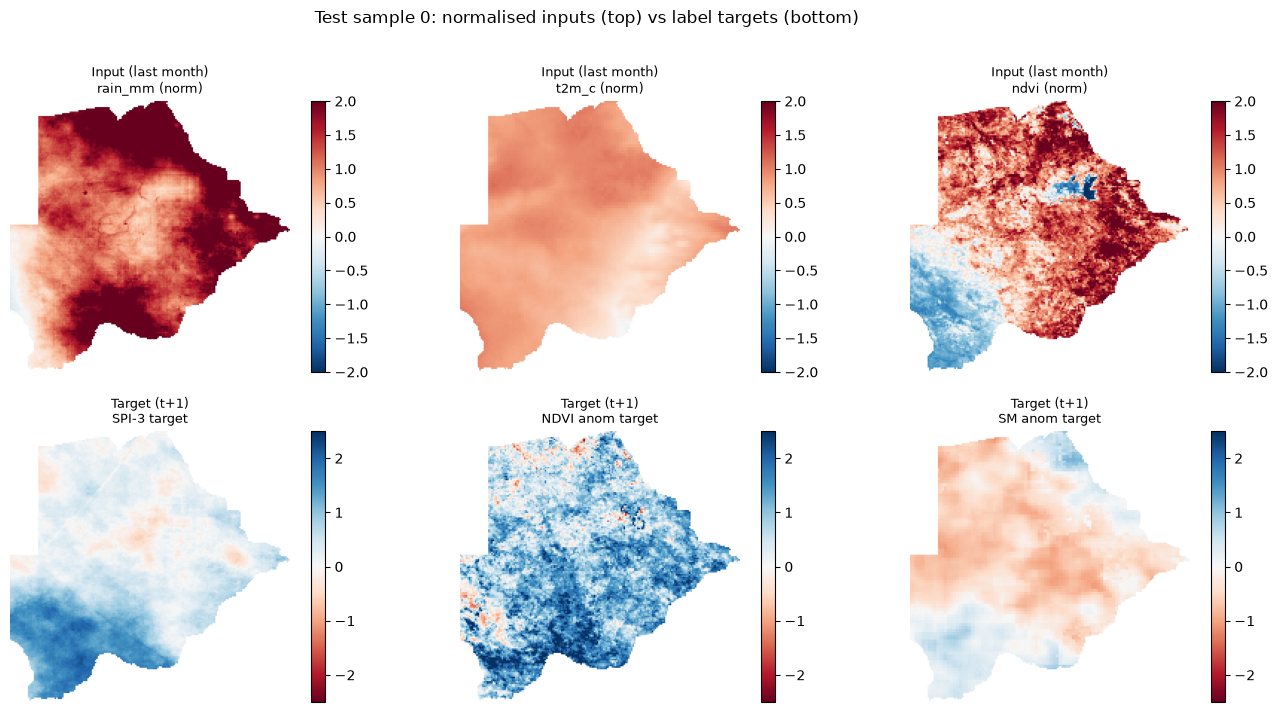

In [5]:
sample = test_ds[0]  # First test window
mask = np.load(CUBE / 'mask.npy')  # (H, W)

fig, axes = plt.subplots(2, 3, figsize=(14, 7))

# Top row: last month of input (normalised), channels 0-2
input_last = sample['x'][-1].numpy()  # (C, H, W), last input month
ch_names = ['rain_mm (norm)', 't2m_c (norm)', 'ndvi (norm)']
for j, (ax, ch, name) in enumerate(zip(axes[0], [0, 1, 2], ch_names)):
    data = input_last[ch].copy()
    data[~mask] = np.nan
    im = ax.imshow(data, cmap='RdBu_r', vmin=-2, vmax=2, origin='upper')
    ax.set_title(f'Input (last month)\n{name}', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

# Bottom row: target labels (horizon=0, i.e. month t+1)
label_names = ['SPI-3 target', 'NDVI anom target', 'SM anom target']
y0 = sample['y'][0].numpy()  # (3, H, W), first target month
for j, (ax, name) in enumerate(zip(axes[1], label_names)):
    data = y0[j].copy()
    data[~mask] = np.nan
    im = ax.imshow(data, cmap='RdBu', vmin=-2.5, vmax=2.5, origin='upper')
    ax.set_title(f'Target (t+1)\n{name}', fontsize=9)
    ax.axis('off')
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Test sample 0: normalised inputs (top) vs label targets (bottom)', y=1.01)
plt.tight_layout()
plt.show()

---
## Step 4 — Baseline scores

Before training anything, we compute two naive baselines:

- **Persistence**: predict next month = last observed month.
  Strong because drought changes slowly — if SPI was −1.5 last month, it'll probably be
  around −1.5 next month too. Any real model must beat this.

- **Climatology**: predict next month = the long-run average for that calendar month.
  Captures seasonal patterns (e.g. December is always wetter). A model that just 
  memorises seasonality will match this.

We evaluate on the **test split** (2022–2026), reporting MAE and F1 drought detection
separately for each of the 3 label channels.

In [7]:
labels = np.load(CUBE / 'labels.npy')  # (T, 3, H, W)
mask   = np.load(CUBE / 'mask.npy')    # (H, W)

label_names = ['SPI-3', 'NDVI anom', 'SM anom']

# --- Persistence ---
pers_preds = persistence_forecast(labels, INPUT_LEN, HORIZON)  # (n_windows, horizon, 3, H, W)
test_start_window = TRAIN_END - INPUT_LEN
pers_preds_test = pers_preds[test_start_window:]

# True labels for test windows
test_targets = []
for s in test_ds.starts:
    test_targets.append(labels[s + INPUT_LEN : s + INPUT_LEN + HORIZON])
test_targets = np.stack(test_targets)  # (n_test, horizon, 3, H, W)

# --- Climatology ---
clim_preds = climatology_forecast(labels, INPUT_LEN, HORIZON, calendar_offset=0)
clim_preds_test = clim_preds[test_start_window:]

print(f'Test windows : {len(test_ds)}')
print()

# Evaluate horizon=1 for each label
H_IDX = 0

rows = []
for c, lname in enumerate(label_names):
    for model_name, preds in [('Persistence', pers_preds_test), ('Climatology', clim_preds_test)]:
        maes, f1s = [], []
        for i in range(len(test_targets)):
            y_true = test_targets[i, H_IDX, c]  # (H, W)
            y_pred = preds[i, H_IDX, c]          # (H, W)
            # Require both target AND prediction to be finite (NaN persistence = failed gamma fit)
            v = np.isfinite(y_true) & np.isfinite(y_pred) & mask
            if v.sum() < 10:
                continue
            m = metric_summary(y_pred, y_true, v)
            maes.append(m['mae'])
            f1s.append(m['f1'])
        rows.append({'Model': model_name, 'Label': lname,
                     'MAE': np.mean(maes), 'F1 (drought)': np.mean(f1s)})

import pandas as pd
df = pd.DataFrame(rows).pivot(index='Model', columns='Label', values=['MAE', 'F1 (drought)'])
print('=== Baseline results (test split, horizon=1 month ahead) ===')
print(df.round(3).to_string())
print('\nYour ConvLSTM needs to beat Persistence MAE on all three labels.')


/Users/andrewsimons/botswana-drought-flood/src/botswana_ds/models/baselines.py:46: RuntimeWarning: Mean of empty slice
  clim[m] = np.nanmean(sel, axis=0)


Test windows : 22

=== Baseline results (test split, horizon=1 month ahead) ===
                  MAE                F1 (drought)               
Label       NDVI anom SM anom  SPI-3    NDVI anom SM anom  SPI-3
Model                                                           
Climatology     0.907   0.941  0.685        0.339   0.207  0.180
Persistence     0.457   0.783  0.593        0.705   0.496  0.414

Your ConvLSTM needs to beat Persistence MAE on all three labels.


---
## Week 4 success criteria

| Check | Expected |
|-------|----------|
| `x.shape` | `(12, 9, 182, 188)` per sample |
| `y.shape` | `(3, 3, 182, 188)` per sample |
| `x.mean()` | ≈ 0 (normalised) |
| `x.std()`  | ≈ 1 (normalised) |
| Persistence MAE (SPI-3) | typically 0.3–0.6 |
| Climatology MAE (SPI-3) | higher than persistence (drought is sticky) |
| DataLoader loads without crash | ✓ |

**Baseline scores saved? Ready for Week 5** — Per-pixel LSTM and the full ConvLSTM training loop.

The model architecture is already written in `src/botswana_ds/models/convlstm.py`.
Week 5 wires it to the DataLoader, writes the training loop, and produces the benchmark table.